# Initial data exploration

This notebook presents a comprehensive **Exploratory Data Analysis (EDA)** on the BTS On-Time Performance dataset.

The questions answered in this notebook, which shape the preprocessing decisions, are:

1. What columns does BTS publish, and which of them are known before departure?
2. How many flights have no usable outcome?
3. How imbalanced is the target?
4. How much cardinality do the categorical columns carry?
5. Which columns are redundant with each other?
6. Does delay vary with time of day, day of week and season?

In [1]:
# Import libraries
from pathlib import Path
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

In [2]:
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RAW_DIR = Path("../data/raw")
csv_paths = sorted(RAW_DIR.rglob("*.csv"))[:12]
for p in csv_paths:
    print(p.name)

On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_2.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_3.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_4.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_5.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_6.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_7.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_8.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_9.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_10.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv


## 1. What BTS publishes

In [4]:
df = pd.concat(
    [pd.read_csv(p, low_memory=False) for p in csv_paths], 
    ignore_index=True
)
print(f"{len(df):,} flights, {df.shape[1]} columns")
df.head(3)

7,001,619 flights, 110 columns


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FirstDepTime,TotalAddGTime,LongestAddGTime,DivAirportLandings,DivReachedDest,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1AirportID,Div1AirportSeqID,Div1WheelsOn,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime,Div2WheelsOff,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2025,1,1,1,3,2025-01-01,AA,19805,AA,N104NN,1,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,12892,1289208,32575,LAX,"Los Angeles, CA",CA,6,California,91,659,656.0,-3.0,0.0,0.0,-1.0,0600-0659,23.0,719.0,1004.0,9.0,1020,1013.0,-7.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,381.0,377.0,345.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,2,4,2025-01-02,AA,19805,AA,N110AN,1,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,12892,1289208,32575,LAX,"Los Angeles, CA",CA,6,California,91,659,652.0,-7.0,0.0,0.0,-1.0,0600-0659,30.0,722.0,1015.0,7.0,1020,1022.0,2.0,2.0,0.0,0.0,1000-1059,0.0,NaN,0.0,381.0,390.0,353.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,3,5,2025-01-03,AA,19805,AA,N106NN,1,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,12892,1289208,32575,LAX,"Los Angeles, CA",CA,6,California,91,659,652.0,-7.0,0.0,0.0,-1.0,0600-0659,13.0,705.0,952.0,11.0,1020,1003.0,-17.0,0.0,0.0,-2.0,1000-1059,0.0,NaN,0.0,381.0,371.0,347.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
div_cols = [c for c in df.columns if c.startswith("Div")]
total_cells = len(df) * len(div_cols)
filled = int(df[div_cols].notna().sum().sum())

print(f"{len(div_cols)} diversion columns")
print(f"{filled:,} non-null diversion values out of {total_cells:,} diversion cells ({filled / total_cells:.4%})")

46 diversion columns
14,233,346 non-null diversion values out of 322,074,474 diversion cells (4.4193%)


### Columns known before departure

Fields recorded during or after the flight cannot serve as model inputs, since they do
not exist at prediction time. A representative sample is measured below.

In [8]:

# Fields BTS records during or after the flight.
post_departure = [
    "DepTime", "DepDelay", "DepDelayMinutes", "DepDel15",
    "TaxiOut", "TaxiIn", "ActualElapsedTime", "AirTime",
    "ArrTime", "ArrDelay", "ArrDelayMinutes",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
]

valid = df.dropna(subset=["ArrDel15"])
available = [
    c for c in post_departure
    if c in valid.columns and pd.api.types.is_numeric_dtype(valid[c])
]

rows = []
for col in available:
    sub = valid[[col, "ArrDel15"]].dropna()
    auc = (
        roc_auc_score(sub["ArrDel15"], sub[col])
        if len(sub) >= 1000 and sub["ArrDel15"].nunique() > 1
        else None
    )
    rows.append({"column": col, "auc": auc, "coverage": len(sub) / len(valid)})

pd.DataFrame(rows).sort_values("auc", ascending=False, na_position="last")

,column,auc,coverage
9,ArrDelay,1.000000,1.000000
10,ArrDelayMinutes,1.000000,1.000000
1,DepDelay,0.922968,1.000000
2,DepDelayMinutes,0.914856,1.000000
3,DepDel15,0.869045,1.000000
0,DepTime,0.654858,1.000000
4,TaxiOut,0.633079,1.000000
8,ArrTime,0.594314,1.000000
6,ActualElapsedTime,0.564768,1.000000
5,TaxiIn,0.549325,1.000000


`ArrDelay` and `ArrDelayMinutes` reach an AUC of 1.0: the target is derived from them by
thresholding at 15 minutes, so they encode it exactly.

`DepDelay` reaches 0.92 and `DepDel15` 0.86. A single field recorded at departure
separates delayed from on-time flights almost perfectly.

The five delay-cause fields return no AUC. Their coverage of 0.19 matches the share of
delayed flights: BTS populates them only when a delay occurred, so within the rows where
they exist the target is constant.

`TaxiOut`, `TaxiIn`, `AirTime` and `ActualElapsedTime` sit between 0.52 and 0.63 —
weaker, but recorded after departure and therefore equally unusable.

## 2. Flights without a usable outcome

Cancelled and diverted flights never arrive as scheduled, so they carry no arrival
delay to predict.

In [9]:
n_total = len(df)
n_cancelled = int((df["Cancelled"] == 1).sum())
n_diverted = int((df["Diverted"] == 1).sum())
n_no_target = int(df["ArrDel15"].isna().sum())

print(f"total          {n_total:,}")
print(f"cancelled      {n_cancelled:,} ({n_cancelled / n_total:.2%})")
print(f"diverted       {n_diverted:,} ({n_diverted / n_total:.2%})")
print(f"missing target {n_no_target:,} ({n_no_target / n_total:.2%})")

total          7,001,619
cancelled      102,876 (1.47%)
diverted       19,258 (0.28%)
missing target 122,135 (1.74%)


## 3. Target balance

`ArrDel15` is BTS's own flag: 1 when the flight arrived 15 or more minutes late.

In [11]:
clean = df[(df["Cancelled"] == 0) & (df["Diverted"] == 0)].dropna(subset=["ArrDel15"])
balance = clean["ArrDel15"].value_counts(normalize=True).sort_index()
print(balance)

print(
    f"\nA model always predicting 'on time' would reach "
    f"{balance[0.0]:.1%} accuracy while being useless - which is why accuracy is not "
    f"used to select the model."
)

ArrDel15
0.0    0.776925
1.0    0.223075
Name: proportion, dtype: float64

A model always predicting 'on time' would reach 77.7% accuracy while being useless - which is why accuracy is not used to select the model.


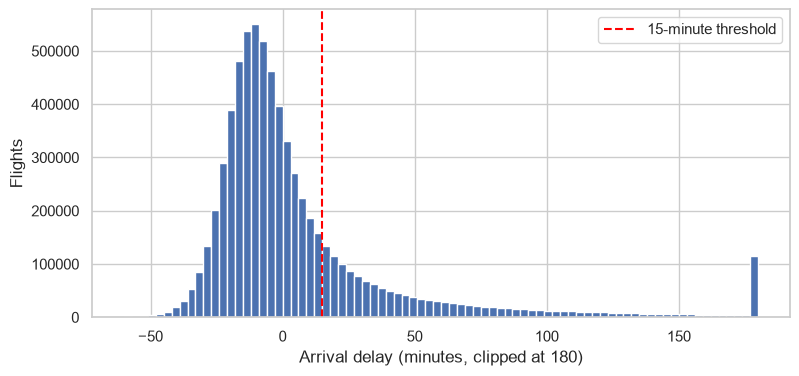

110,121 flights delayed more than 180 minutes (1.60%)


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
clean["ArrDelay"].clip(-60, 180).hist(bins=80, ax=ax)
ax.axvline(15, color="red", linestyle="--", label="15-minute threshold")
ax.set_xlabel("Arrival delay (minutes, clipped at 180)")
ax.set_ylabel("Flights")
ax.legend()
plt.show()

n_clipped = int((clean["ArrDelay"] > 180).sum())
print(f"{n_clipped:,} flights delayed more than 180 minutes ({n_clipped / len(clean):.2%})")

## 4. Cardinality of the categorical columns

In [13]:
cat_cols = [
    "Reporting_Airline",
    "Origin",
    "Dest",
    "OriginCityName",
    "DestCityName",
    "OriginState",
    "DestState",
]
cardinality = clean[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

Origin               352
Dest                 352
OriginCityName       346
DestCityName         346
OriginState           52
DestState             52
Reporting_Airline     14
dtype: int64


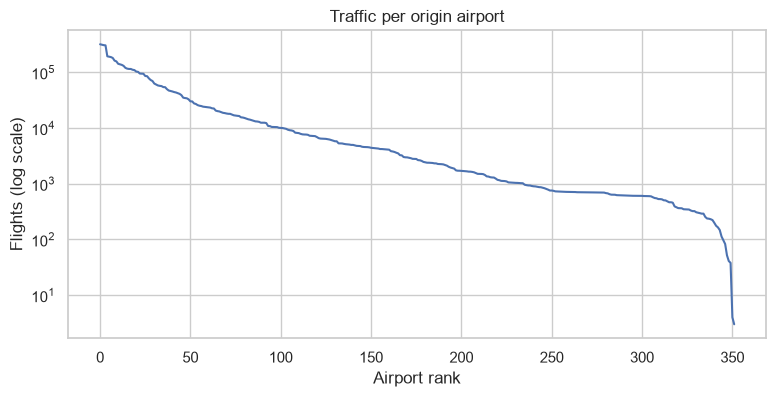

threshold   100: 345 airports kept, 100.0% of flights covered
threshold   500: 314 airports kept, 99.9% of flights covered
threshold  1000: 235 airports kept, 99.1% of flights covered
threshold  5000: 139 airports kept, 95.5% of flights covered


In [14]:
counts = clean["Origin"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(counts)), counts.values)
ax.set_yscale("log")
ax.set_xlabel("Airport rank")
ax.set_ylabel("Flights (log scale)")
ax.set_title("Traffic per origin airport")
plt.show()

for threshold in [100, 500, 1000, 5000]:
    kept = int((counts >= threshold).sum())
    covered = counts[counts >= threshold].sum() / counts.sum()
    print(f"threshold {threshold:>5}: {kept:>3} airports kept, {covered:.1%} of flights covered")

## 5. Redundancy between columns

Several columns describe the same thing at different granularity. Keeping all of them
destabilises linear coefficients and splits the SHAP contribution across near-duplicates.

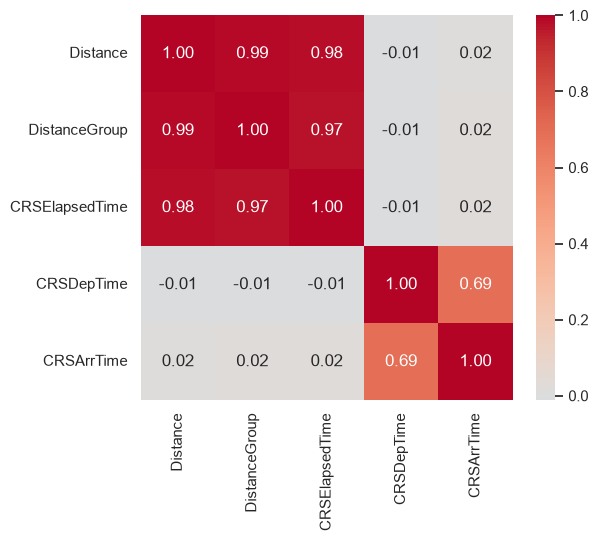

In [15]:
numeric_cols = ["Distance", "DistanceGroup", "CRSElapsedTime", "CRSDepTime", "CRSArrTime"]
corr = clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.show()

In [16]:

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if min(table.shape) < 2:
        return 0.0
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


sample = clean.sample(min(50_000, len(clean)), random_state=42)
for a, b in [
    ("Origin", "OriginCityName"),
    ("Origin", "OriginState"),
    ("OriginCityName", "OriginState"),
    ("Origin", "Reporting_Airline"),
]:
    print(f"{a} vs {b}: {cramers_v(sample[a], sample[b]):.3f}")

Origin vs OriginCityName: 1.000
Origin vs OriginState: 1.000
OriginCityName vs OriginState: 1.000
Origin vs Reporting_Airline: 0.477


## 6. When do delays happen

Whether the schedule alone carries signal, before any weather is added.

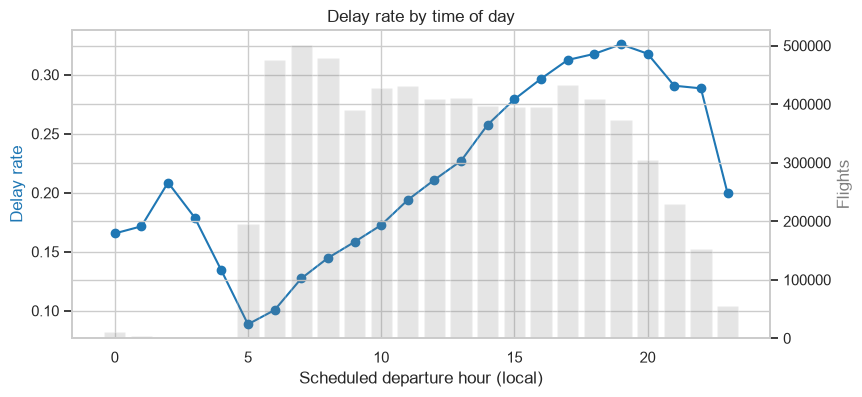

In [17]:
clean = clean.copy()
clean["DepHour"] = clean["CRSDepTime"].replace(2400, 0) // 100
by_hour = clean.groupby("DepHour")["ArrDel15"].agg(["mean", "size"])

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(by_hour.index, by_hour["mean"], marker="o", color="tab:blue")
ax1.set_xlabel("Scheduled departure hour (local)")
ax1.set_ylabel("Delay rate", color="tab:blue")

ax2 = ax1.twinx()
ax2.bar(by_hour.index, by_hour["size"], alpha=0.2, color="tab:grey")
ax2.set_ylabel("Flights", color="tab:grey")

ax1.set_title("Delay rate by time of day")
plt.show()

In [55]:
by_dow = clean.groupby("DayOfWeek")["ArrDel15"].mean()
print(by_dow)

check = clean[["FlightDate", "DayOfWeek"]].drop_duplicates().head(7).copy()
check["day_name"] = pd.to_datetime(check["FlightDate"]).dt.day_name()
print("\nBTS weekday convention:")
print(check.sort_values("DayOfWeek").to_string(index=False))

DayOfWeek
1    0.226388
2    0.153129
3    0.132801
4    0.173680
5    0.194624
6    0.216392
7    0.225945
Name: ArrDel15, dtype: float64

BTS weekday convention:
FlightDate  DayOfWeek  day_name
2025-01-06          1    Monday
2025-01-07          2   Tuesday
2025-01-01          3 Wednesday
2025-01-02          4  Thursday
2025-01-03          5    Friday
2025-01-04          6  Saturday
2025-01-05          7    Sunday


In [18]:
by_carrier = (
    clean.groupby("Reporting_Airline")["ArrDel15"].agg(["mean", "size"]).sort_values("mean")
)
print(by_carrier)

                       mean     size
Reporting_Airline                   
HA                 0.172811    79335
DL                 0.197942  1012427
OO                 0.207217   825202
MQ                 0.210393   291835
WN                 0.213951  1376837
NK                 0.214084   191191
UA                 0.214674   786377
YX                 0.215113   334043
AS                 0.231008   241927
G4                 0.249654   129892
AA                 0.257114   952841
B6                 0.261523   226703
OH                 0.275298   236682
F9                 0.279116   194192


## Implications for preprocessing

- **Exclude the post-departure fields.** Several reach an AUC above 0.85 on their
  own, and `ArrDelay` reaches 1.0 by construction. None exists at prediction time.
- **Drop cancelled and diverted flights.** No arrival, no target.
- **Do not select models on accuracy.** Always predicting "on time" already scores 0.77.
- **Group rare airports into an OTHER bucket.** A threshold of 1000 keeps 235 airports while covering 99.1% of flights.
- **Feature selection.** Implementing feature selection is recommended to identify correlated or uninformative features.
